# 🔮 OnePilot — Forecasting | Notebook 3 : Prophet
**Modèle** : Facebook/Meta Prophet  
**Données** : `/tmp/northwind_monthly_train.csv` + `test.csv`  
**Output** : MAE + prévisions sauvegardées pour l'Ensemble (Notebook 5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('prophet').setLevel(logging.ERROR)

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})
print('✅ Imports OK')

✅ Imports OK


In [2]:
# ── Chargement des données ────────────────────────────────────────
train = pd.read_csv('/tmp/northwind_monthly_train.csv', index_col='date', parse_dates=True)
test  = pd.read_csv('/tmp/northwind_monthly_test.csv',  index_col='date', parse_dates=True)
full  = pd.read_csv('/tmp/northwind_monthly.csv',       index_col='date', parse_dates=True)

train['revenu'] = train['revenu'].astype(float)
test['revenu']  = test['revenu'].astype(float)
full['revenu']  = full['revenu'].astype(float)

# Prophet exige deux colonnes : ds (date) et y (valeur)
df_train_prophet = pd.DataFrame({
    'ds': train.index,
    'y':  train['revenu'].values
})
df_test_prophet = pd.DataFrame({
    'ds': test.index,
    'y':  test['revenu'].values
})

print(f'✅ Données chargées')
print(f'   Train : {len(df_train_prophet)} mois ({df_train_prophet["ds"].min().strftime("%Y-%m")} → {df_train_prophet["ds"].max().strftime("%Y-%m")})')
print(f'   Test  : {len(df_test_prophet)} mois ({df_test_prophet["ds"].min().strftime("%Y-%m")} → {df_test_prophet["ds"].max().strftime("%Y-%m")})')
print(f'\n   Format Prophet (ds + y) :')
print(df_train_prophet.head(3).to_string(index=False))

✅ Données chargées
   Train : 18 mois (1996-07 → 1997-12)
   Test  : 5 mois (1998-01 → 1998-05)

   Format Prophet (ds + y) :
        ds        y
1996-07-01 27861.89
1996-08-01 25485.27
1996-09-01 26381.40


In [3]:
# ── Entraînement Prophet ──────────────────────────────────────────
# Avec 18 points mensuels :
# - yearly_seasonality=False  (pas assez de données pour 2 cycles complets)
# - weekly_seasonality=False  (données mensuelles, pas journalières)
# - changepoint_prior_scale=0.3  (plus sensible aux changements de tendance)

print('🔮 Entraînement Prophet...')

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,   # flexibilité de la tendance
    seasonality_mode='additive',
    interval_width=0.95            # IC à 95%
)

model.fit(df_train_prophet)
print('✅ Modèle entraîné')
print(f'   Changepoints détectés : {len(model.changepoints)}')
print(f'   Mode saisonnalité     : additif')
print(f'   Flexibilité tendance  : {model.changepoint_prior_scale}')

22:52:46 - cmdstanpy - INFO - Chain [1] start processing
22:52:46 - cmdstanpy - INFO - Chain [1] done processing


🔮 Entraînement Prophet...
✅ Modèle entraîné
   Changepoints détectés : 13
   Mode saisonnalité     : additif
   Flexibilité tendance  : 0.3


In [4]:
# ── Prévision ─────────────────────────────────────────────────────
n_test    = len(df_test_prophet)
n_horizon = 3  # mois au-delà du test
n_total   = n_test + n_horizon

# Prophet génère un DataFrame de dates futures
future = model.make_future_dataframe(periods=n_total, freq='MS')
forecast = model.predict(future)

# Extraire uniquement les périodes futures (après le train)
forecast_future = forecast[forecast['ds'] > df_train_prophet['ds'].max()].copy()
forecast_future = forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(n_total)
forecast_future.columns = ['date', 'forecast', 'lower_95', 'upper_95']
forecast_future = forecast_future.set_index('date')

# Forcer les prévisions positives
forecast_future = forecast_future.clip(lower=0)

print('✅ Prévisions générées')
print(forecast_future.round(0).to_string())

✅ Prévisions générées
            forecast  lower_95  upper_95
date                                    
1998-01-01   62815.0   45273.0   80044.0
1998-02-01   64631.0   47499.0   81925.0
1998-03-01   66271.0   49271.0   84134.0
1998-04-01   68086.0   50275.0   85395.0
1998-05-01   69843.0   52516.0   86683.0
1998-06-01   71658.0   54244.0   88165.0
1998-07-01   73415.0   57438.0   90975.0
1998-08-01   75231.0   57386.0   92711.0


In [5]:
# ── Calcul du MAE ─────────────────────────────────────────────────
forecast_test = forecast_future['forecast'].iloc[:n_test]
test_values   = df_test_prophet['y'].values

mae  = mean_absolute_error(test_values, forecast_test.values)
mape = np.mean(np.abs((test_values - forecast_test.values) / test_values)) * 100

print('='*45)
print('  PERFORMANCE PROPHET')
print('='*45)
print(f'  MAE  : {mae:,.0f} €')
print(f'  MAPE : {mape:.1f} %')
print(f'  Horizon évalué : {n_test} mois')
print()
print('  Comparatif réel vs prévu :')
comp = pd.DataFrame({
    'Réel'  : test_values.round(0),
    'Prévu' : forecast_test.values.round(0),
    'Erreur': (test_values - forecast_test.values).round(0)
}, index=df_test_prophet['ds'].dt.strftime('%Y-%m').values)
print(comp.to_string())

# Comparaison avec SARIMA
try:
    sarima_metrics = pd.read_csv('/tmp/sarima_metrics.csv', index_col=0, header=None)[1]
    sarima_mae = float(sarima_metrics.get('mae', 0))
    print(f'\n  Comparaison :')
    print(f'  SARIMA MAE : {sarima_mae:,.0f} €')
    print(f'  Prophet MAE: {mae:,.0f} €')
    winner = 'Prophet ✅' if mae < sarima_mae else 'SARIMA ✅'
    print(f'  Meilleur   : {winner}')
except: pass

  PERFORMANCE PROPHET
  MAE  : 42,399 €
  MAPE : 86.2 %
  Horizon évalué : 5 mois

  Comparatif réel vs prévu :
             Réel    Prévu   Erreur
1998-01   94222.0  62815.0  31407.0
1998-02   99415.0  64631.0  34785.0
1998-03  104854.0  66271.0  38584.0
1998-04  123799.0  68086.0  55713.0
1998-05   18334.0  69843.0 -51509.0

  Comparaison :
  SARIMA MAE : 40,390 €
  Prophet MAE: 42,399 €
  Meilleur   : SARIMA ✅


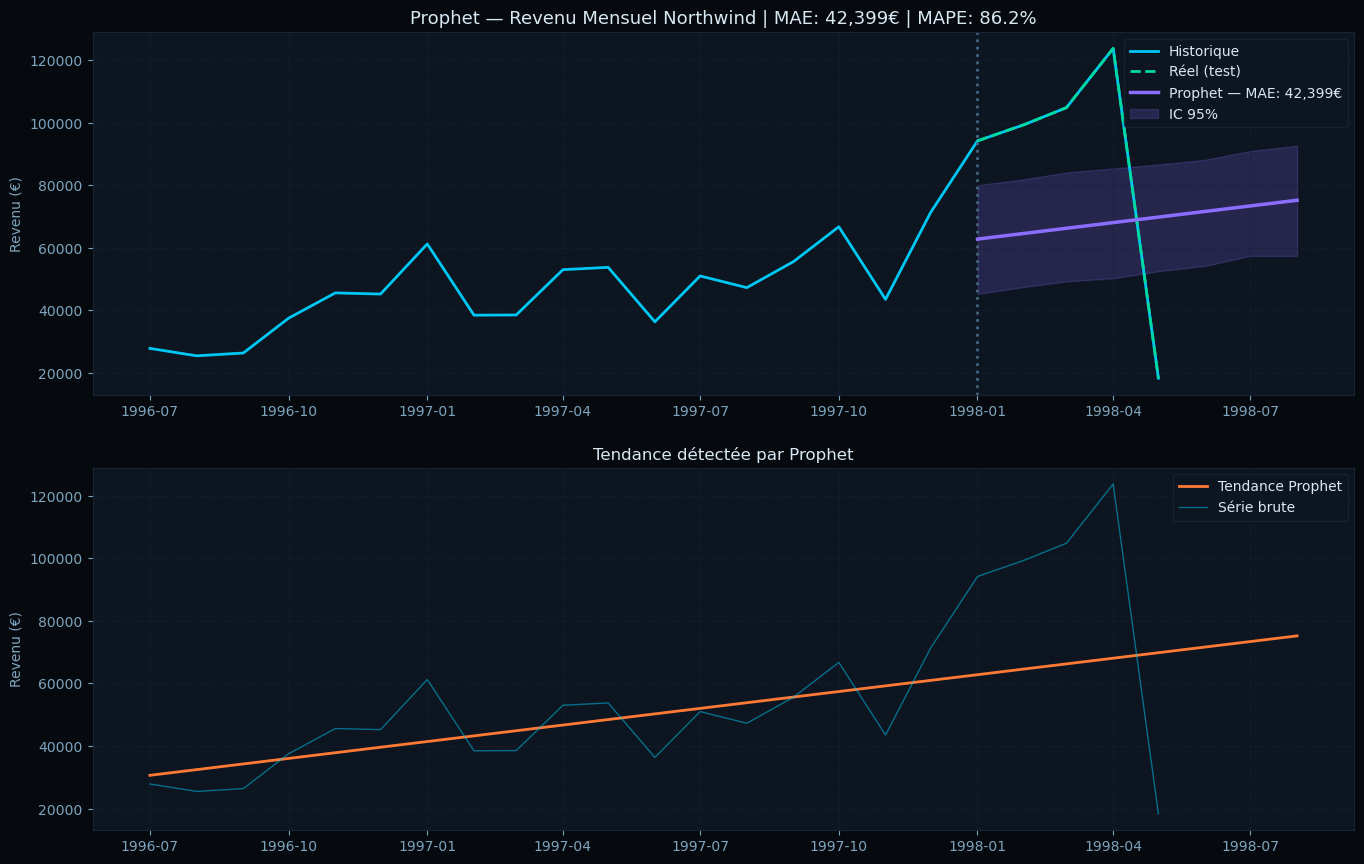

✅ Graphique sauvegardé → /tmp/prophet_forecast.png


In [6]:
# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Graphique 1 : Prévision principale ──
ax1 = axes[0]
ax1.plot(full.index, full['revenu'], color='#00c8f5', lw=2, label='Historique')
ax1.plot(test.index, test['revenu'], color='#00d9a0', lw=2,
         linestyle='--', label='Réel (test)', zorder=4)
ax1.plot(forecast_future.index, forecast_future['forecast'],
         color='#8b6eff', lw=2.5, label=f'Prophet — MAE: {mae:,.0f}€', zorder=5)
ax1.fill_between(
    forecast_future.index,
    forecast_future['lower_95'],
    forecast_future['upper_95'],
    alpha=0.2, color='#8b6eff', label='IC 95%'
)
ax1.axvline(x=test.index[0], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f'Prophet — Revenu Mensuel Northwind | MAE: {mae:,.0f}€ | MAPE: {mape:.1f}%',
              color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Revenu (€)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# ── Graphique 2 : Décomposition tendance ──
ax2 = axes[1]
trend = forecast[['ds', 'trend']].set_index('ds')
ax2.plot(trend.index, trend['trend'], color='#ff7a35', lw=2, label='Tendance Prophet')
ax2.plot(full.index, full['revenu'], color='#00c8f5', lw=1, alpha=0.5, label='Série brute')
ax2.set_title('Tendance détectée par Prophet', color='#d8e8f2', fontsize=12)
ax2.set_ylabel('Revenu (€)', color='#7ea4be')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax2.grid(True)

plt.tight_layout(pad=2)
plt.savefig('/tmp/prophet_forecast.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/prophet_forecast.png')

In [7]:
# ── Sauvegarde pour Notebook 5 (Ensemble) ────────────────────────
forecast_future.to_csv('/tmp/prophet_forecast.csv')
pd.Series({'mae': mae, 'mape': mape, 'model': 'Prophet'}).to_csv('/tmp/prophet_metrics.csv')

print('✅ Résultats sauvegardés :')
print('   /tmp/prophet_forecast.csv  → prévisions + IC 95%')
print('   /tmp/prophet_metrics.csv   → MAE, MAPE')
print()
print(f'📊 Résumé Prophet :')
print(f'   MAE    : {mae:,.0f} €')
print(f'   MAPE   : {mape:.1f} %')
print()
print('→ Prochain notebook : Notebook 4 — LSTM')

✅ Résultats sauvegardés :
   /tmp/prophet_forecast.csv  → prévisions + IC 95%
   /tmp/prophet_metrics.csv   → MAE, MAPE

📊 Résumé Prophet :
   MAE    : 42,399 €
   MAPE   : 86.2 %

→ Prochain notebook : Notebook 4 — LSTM
